In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install xgboost imbalanced-learn

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

In [5]:
path = "/content/drive/MyDrive/JIT_bug_prediction/data/apachejit.csv"

df = pd.read_csv(path)

In [6]:
df['buggy'] = df['buggy'].astype(str).str.lower()

df['buggy'] = df['buggy'].map({
    'false': 0,
    'true': 1
})

In [7]:
df = df.sort_values(by='author_date')

In [8]:
features = [
    'la',
    'ld',
    'nf',
    'nd',
    'ns',
    'ent',
    'ndev',
    'age',
    'nuc',
    'aexp',
    'arexp',
    'asexp'
]

X = df[features]

y = df['buggy']

In [9]:
X = X.fillna(0)

In [10]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [11]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [12]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(
    X_train_resampled,
    y_train_resampled
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

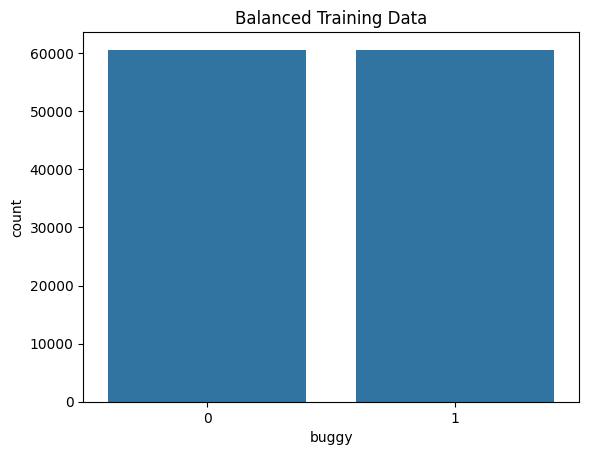

In [13]:
sns.countplot(x=y_train_resampled)

plt.title("Balanced Training Data")

plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_resampled
)

X_test_scaled = scaler.transform(
    X_test
)

In [16]:
lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train_resampled
)

LogisticRegression(max_iter=5000, random_state=42)

In [17]:
y_pred = lr_model.predict(X_test_scaled)

y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

In [18]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.6923834075462855
Precision: 0.30455239064089523
Recall   : 0.6864431069074234
F1 Score : 0.4219149123579671
ROC AUC  : 0.7611698934873109


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79     17846
           1       0.30      0.69      0.42      3489

    accuracy                           0.69     21335
   macro avg       0.61      0.69      0.61     21335
weighted avg       0.82      0.69      0.73     21335



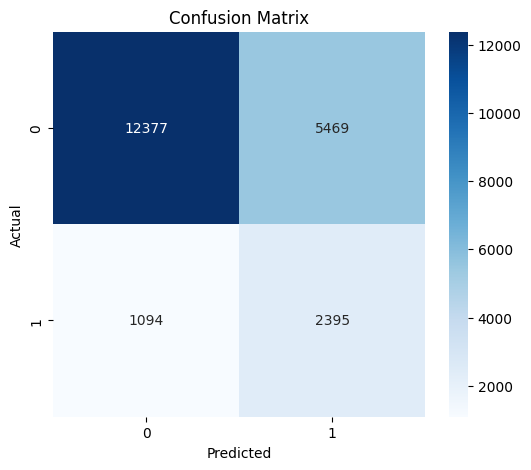

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

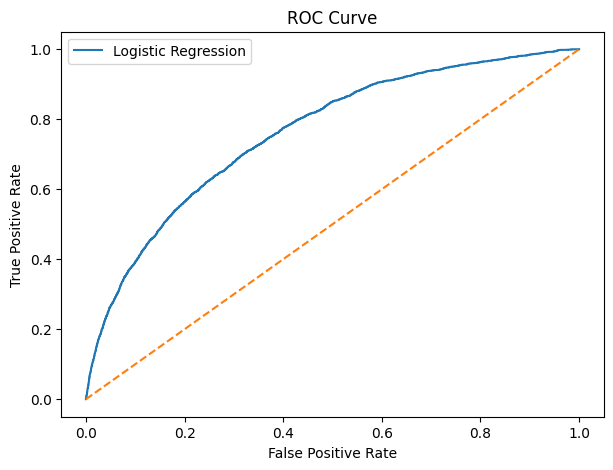

In [28]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/roc_curve_lr.png"
)

plt.show()

In [30]:
import joblib

joblib.dump(
    lr_model,
    "/content/drive/MyDrive/JIT_bug_prediction/models/logistic_regression.pkl"
)

['/content/drive/MyDrive/JIT_bug_prediction/models/logistic_regression.pkl']